# **ANALISIS FAKTOR & FACTOR SCORES**

#Install Library

In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=8167738c5763031eefb6bb1f7753ae1dc802ec82e0a9e3a6fc3998f5945c44f9
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


#Import Library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

#Load Data

In [ ]:
url = "https://raw.githubusercontent.com/naiarch/faktor-analisis-dan-clustering-data-bps/main/dataset_paper_statmul.csv"
df = pd.read_csv(url)

provinsi = df['Provinsi'].values
df_num = df.drop(columns=['Provinsi'])
df_num.head()

,AHH,Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit,Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas,Persentase_Penduduk_Miskin,Kepadatan_Penduduk,Persentase Keluhan Kesehatan,RLS,TPT,HLS
0,70.485,66.0,363.0,12.64,98.0,25.58,9.95,5.75,14.39
1,70.330,176.0,624.0,7.19,215.0,23.99,10.18,5.60,13.49
2,70.380,64.0,280.0,5.42,139.0,30.10,9.72,5.75,14.30
3,72.570,66.0,244.0,6.36,75.0,23.60,9.69,3.70,13.42
4,72.090,39.0,208.0,7.26,76.0,23.73,9.26,4.48,13.14


#Cek Missing Value

In [ ]:
print("Jumlah Missing Value Setiap Variabel")
print(df_num.isnull().sum())
print("\nTotal Missing Value :", df_num.isnull().sum().sum())

if df_num.isnull().sum().sum() == 0:
    print("Kesimpulan : Tidak terdapat missing value pada data.")
else:
    print("Kesimpulan : Terdapat missing value pada data.")

Jumlah Missing Value Setiap Variabel
AHH                                                            0
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit    0
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas      0
Persentase_Penduduk_Miskin                                     0
Kepadatan_Penduduk                                             0
Persentase Keluhan Kesehatan                                   0
RLS                                                            0
TPT                                                            0
HLS                                                            0
dtype: int64

Total Missing Value : 0
Kesimpulan : Tidak terdapat missing value pada data.


#Cek Outlier (Z-score)

In [ ]:
z_scores = np.abs(zscore(df_num))
outlier = (z_scores > 3)

print("Jumlah Outlier Setiap Variabel")
print(pd.DataFrame(outlier, columns=df_num.columns).sum())
print("\nTotal Outlier :", outlier.sum())

Jumlah Outlier Setiap Variabel
AHH                                                            0
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit    2
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas      1
Persentase_Penduduk_Miskin                                     1
Kepadatan_Penduduk                                             1
Persentase Keluhan Kesehatan                                   0
RLS                                                            1
TPT                                                            0
HLS                                                            2
dtype: int64

Total Outlier : 8


#Uji Normalitas Shapiro-Wilk

In [ ]:
print("Uji Normalitas Shapiro-Wilk\n")

for kolom in df_num.columns:
    stat, p = stats.shapiro(df_num[kolom])
    print(f"Variabel : {kolom}")
    print(f"Statistic = {stat:.4f}")
    print(f"P-value   = {p:.4f}")
    if p > 0.05:
        print("Keputusan : H0 gagal ditolak")
        print("Kesimpulan: Data berdistribusi normal.\n")
    else:
        print("Keputusan : H0 ditolak")
        print("Kesimpulan: Data tidak berdistribusi normal.\n")

Uji Normalitas Shapiro-Wilk

Variabel : AHH
Statistic = 0.9811
P-value   = 0.7553
Keputusan : H0 gagal ditolak
Kesimpulan: Data berdistribusi normal.

Variabel : Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit
Statistic = 0.6326
P-value   = 0.0000
Keputusan : H0 ditolak
Kesimpulan: Data tidak berdistribusi normal.

Variabel : Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas
Statistic = 0.7286
P-value   = 0.0000
Keputusan : H0 ditolak
Kesimpulan: Data tidak berdistribusi normal.

Variabel : Persentase_Penduduk_Miskin
Statistic = 0.8586
P-value   = 0.0002
Keputusan : H0 ditolak
Kesimpulan: Data tidak berdistribusi normal.

Variabel : Kepadatan_Penduduk
Statistic = 0.2411
P-value   = 0.0000
Keputusan : H0 ditolak
Kesimpulan: Data tidak berdistribusi normal.

Variabel : Persentase Keluhan Kesehatan
Statistic = 0.9722
P-value   = 0.4545
Keputusan : H0 gagal ditolak
Kesimpulan: Data berdistribusi normal.

Variabel : RLS
Statistic = 0.8706
P-value   = 0.0004
Keputusan : H

Berdasarkan hasil Uji Normalitas Shapiro-Wilk, sebagian variabel memiliki nilai p-value kurang dari 0,05 sehingga H₀ ditolak dan data pada variabel tersebut tidak berdistribusi normal. Namun demikian, analisis faktor tetap dapat dilanjutkan karena kelayakan analisis faktor lebih ditentukan oleh hasil Uji Bartlett, KMO, dan MSA yang akan dilakukan pada tahap berikutnya.

# Analisis Korelasi (Matriks Korelasi/Heatmap)

                                                      AHH  \
AHH                                                 1.000   
Desa/Kelurahan Yang Memiliki Sarana Kesehatan -...  0.508   
Desa/Kelurahan Yang Memiliki Sarana Kesehatan -...  0.355   
Persentase_Penduduk_Miskin                         -0.716   
Kepadatan_Penduduk                                  0.303   
Persentase Keluhan Kesehatan                        0.384   
RLS                                                 0.426   
TPT                                                 0.291   
HLS                                                 0.402   

                                                    Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit  \
AHH                                                                                             0.508             
Desa/Kelurahan Yang Memiliki Sarana Kesehatan -...                                              1.000             
Desa/Kelurahan Yang Memiliki Sarana Kesehata

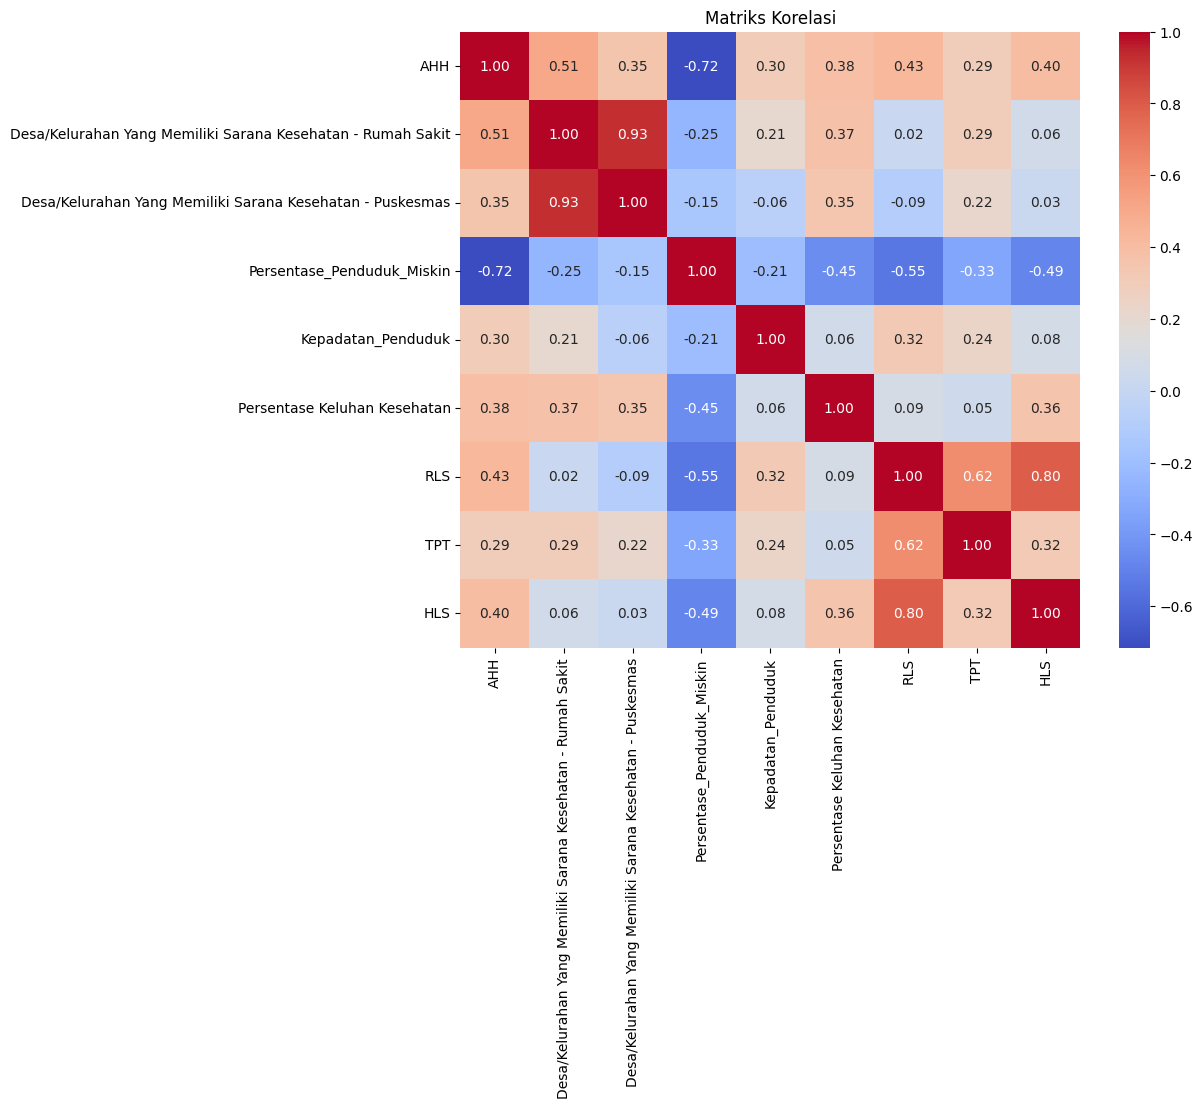

In [ ]:
corr_matrix = df_num.corr()

print(corr_matrix.round(3))

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f")

plt.title("Matriks Korelasi")
plt.show()

# Standarisasi Data

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(df_num)
X = pd.DataFrame(X, columns=df_num.columns)
X.head()

,AHH,Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit,Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas,Persentase_Penduduk_Miskin,Kepadatan_Penduduk,Persentase Keluhan Kesehatan,RLS,TPT,HLS
0,-0.034791,-0.039935,0.376432,0.314411,-0.225345,0.285557,0.580091,0.981923,1.170710
1,-0.093759,1.254067,1.438882,-0.553089,-0.179906,0.039327,0.782972,0.874434,0.277995
2,-0.074737,-0.063462,0.038564,-0.834827,-0.209422,0.985534,0.377210,0.981923,1.081439
3,0.758435,-0.039935,-0.107980,-0.685203,-0.234277,-0.021069,0.350747,-0.487095,0.208561
4,0.575822,-0.357553,-0.254525,-0.541946,-0.233889,-0.000937,-0.028552,0.071848,-0.069172


# Uji Bartlett

In [ ]:
chi_square_value, p_value = calculate_bartlett_sphericity(X)

print("Uji Bartlett")
print("Chi-Square :", round(chi_square_value, 4))
print("P-value    :", round(p_value, 4))

if p_value < 0.05:
    print("\nKeputusan : H0 ditolak")
    print("Kesimpulan : Terdapat korelasi antar variabel sehingga analisis faktor layak dilakukan.")
else:
    print("\nKeputusan : H0 gagal ditolak")
    print("Kesimpulan : Tidak terdapat korelasi yang memadai antar variabel sehingga analisis faktor tidak layak dilakukan.")

Uji Bartlett
Chi-Square : 234.993
P-value    : 0.0

Keputusan : H0 ditolak
Kesimpulan : Terdapat korelasi antar variabel sehingga analisis faktor layak dilakukan.


Berdasarkan hasil Uji Bartlett diperoleh nilai p-value kurang dari 0,05 sehingga H₀ ditolak. Hal ini menunjukkan bahwa terdapat korelasi yang signifikan antar variabel, sehingga data memenuhi syarat untuk dilakukan analisis faktor.

# Uji KMO (Kaiser-Meyer-Olkin)

In [ ]:
kmo_all, kmo_model = calculate_kmo(X)

print("Nilai KMO =", round(kmo_model, 4))

# Interpretasi KMO berdasarkan kategorisasi Kaiser (1974)
if kmo_model >= 0.90:
    kategori = "Marvelous (Luar Biasa)"
elif kmo_model >= 0.80:
    kategori = "Meritorious (Sangat Baik)"
elif kmo_model >= 0.70:
    kategori = "Middling (Baik)"
elif kmo_model >= 0.60:
    kategori = "Mediocre (Cukup Baik)"
elif kmo_model >= 0.50:
    kategori = "Miserable (Cukup / Minimum)"
else:
    kategori = "Unacceptable (Tidak Layak)"

print(f"Kategori KMO : {kategori}")

if kmo_model >= 0.5:
    print("Kesimpulan : Data layak digunakan dalam analisis faktor.")
else:
    print("Kesimpulan : Data tidak layak digunakan dalam analisis faktor.")

Nilai KMO = 0.5336
Kategori KMO : Miserable (Cukup / Minimum)
Kesimpulan : Data layak digunakan dalam analisis faktor.


Nilai KMO yang diperoleh berada di atas 0,5 sehingga data memenuhi syarat minimum kelayakan untuk dilakukan analisis faktor. Meskipun nilai KMO berada pada kategori minimum (*miserable*), analisis faktor masih dapat dilanjutkan dengan mempertimbangkan hasil uji MSA pada tiap variabel.

# MSA (Measure of Sampling Adequacy) & Eliminasi Variabel

In [ ]:
msa = pd.DataFrame({
    "Variabel": X.columns,
    "MSA": kmo_all
}).sort_values(by="MSA", ascending=False).reset_index(drop=True)

print("Nilai MSA Setiap Variabel:")
print(msa.to_string(index=False))

var_drop = msa[msa["MSA"] < 0.5]["Variabel"].tolist()
print(f"\nVariabel dengan MSA < 0.5 (akan dieliminasi): {var_drop}")

Nilai MSA Setiap Variabel:
                                                   Variabel      MSA
                                                        AHH 0.749786
                                 Persentase_Penduduk_Miskin 0.698925
                                                        TPT 0.553262
                               Persentase Keluhan Kesehatan 0.526602
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit 0.504410
                                                        RLS 0.504327
                                                        HLS 0.491422
  Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas 0.474058
                                         Kepadatan_Penduduk 0.255731

Variabel dengan MSA < 0.5 (akan dieliminasi): ['HLS', 'Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas', 'Kepadatan_Penduduk']


In [ ]:
# Eliminasi variabel dengan MSA < 0.5 secara iteratif
X_iter = X.copy()

iteration = 1
while True:
    kmo_all_iter, kmo_model_iter = calculate_kmo(X_iter)
    msa_iter = pd.Series(kmo_all_iter, index=X_iter.columns)
    var_to_drop = msa_iter[msa_iter < 0.5].index.tolist()

    if not var_to_drop:
        print(f"Iterasi {iteration}: Semua variabel memiliki MSA >= 0.5. Proses selesai.")
        break

    # Drop variabel dengan MSA terendah satu per satu
    drop_one = msa_iter[msa_iter < 0.5].idxmin()
    print(f"Iterasi {iteration}: Mengeliminasi variabel '{drop_one}' (MSA = {msa_iter[drop_one]:.4f})")
    X_iter = X_iter.drop(columns=[drop_one])
    iteration += 1

print(f"\nVariabel yang digunakan setelah eliminasi: {list(X_iter.columns)}")
print(f"Nilai KMO setelah eliminasi: {kmo_model_iter:.4f}")

Iterasi 1: Mengeliminasi variabel 'Kepadatan_Penduduk' (MSA = 0.2557)
Iterasi 2: Mengeliminasi variabel 'HLS' (MSA = 0.4904)
Iterasi 3: Semua variabel memiliki MSA >= 0.5. Proses selesai.

Variabel yang digunakan setelah eliminasi: ['AHH', 'Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit', 'Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas', 'Persentase_Penduduk_Miskin', 'Persentase Keluhan Kesehatan', 'RLS', 'TPT']
Nilai KMO setelah eliminasi: 0.6344


Proses eliminasi iteratif dilakukan dengan membuang satu variabel (yang memiliki nilai MSA paling rendah di bawah 0,5) pada setiap iterasi, kemudian menghitung ulang nilai KMO dan MSA hingga seluruh variabel yang tersisa memiliki MSA ≥ 0,5. Variabel yang digunakan selanjutnya adalah variabel yang lolos proses eliminasi ini.

## Re-Uji Bartlett dan KMO Setelah Eliminasi Variabel

In [ ]:
chi2_final, p_final = calculate_bartlett_sphericity(X_iter)
kmo_all_final, kmo_final = calculate_kmo(X_iter)

print("=== Hasil Uji Setelah Eliminasi ===")
print(f"Bartlett Chi-Square : {chi2_final:.4f}  |  P-value : {p_final:.4f}")
print(f"KMO Overall         : {kmo_final:.4f}")
print()

msa_final = pd.DataFrame({
    "Variabel": X_iter.columns,
    "MSA"      : kmo_all_final
}).sort_values("MSA", ascending=False).reset_index(drop=True)

print("MSA Setiap Variabel (setelah eliminasi):")
print(msa_final.to_string(index=False))

=== Hasil Uji Setelah Eliminasi ===
Bartlett Chi-Square : 157.3420  |  P-value : 0.0000
KMO Overall         : 0.6344

MSA Setiap Variabel (setelah eliminasi):
                                                   Variabel      MSA
                               Persentase Keluhan Kesehatan 0.796077
                                 Persentase_Penduduk_Miskin 0.691619
                                                        AHH 0.674709
                                                        RLS 0.638317
                                                        TPT 0.618524
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit 0.571997
  Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas 0.568075


# Analisis Faktor — Eigenvalue

In [ ]:
fa_init = FactorAnalyzer(rotation=None)
fa_init.fit(X_iter)

ev, v = fa_init.get_eigenvalues()

eigen = pd.DataFrame({
    "Faktor"    : range(1, len(ev)+1),
    "Eigenvalue": ev.round(4)
})
print(eigen.to_string(index=False))

jumlah_faktor = sum(ev > 1)
print(f"\nJumlah faktor dengan eigenvalue > 1 : {jumlah_faktor}")

 Faktor  Eigenvalue
      1      3.1360
      2      1.7289
      3      1.0377
      4      0.5730
      5      0.2504
      6      0.2204
      7      0.0537

Jumlah faktor dengan eigenvalue > 1 : 3


Berdasarkan kriteria Kaiser, faktor yang dipertahankan adalah faktor dengan eigenvalue > 1. Jumlah faktor yang terbentuk ditentukan dari hasil di atas.

# Scree Plot

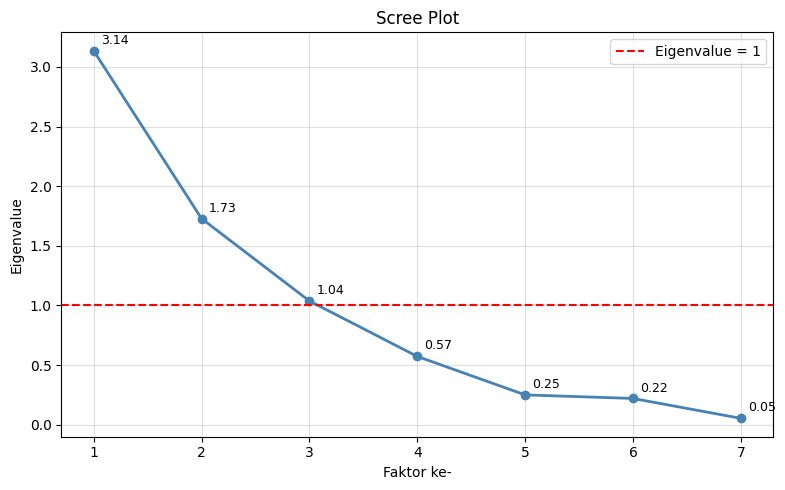

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ev)+1), ev, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=1, color='red', linestyle='--', label='Eigenvalue = 1')

for i, val in enumerate(ev):
    plt.annotate(f'{val:.2f}', (i+1, val), textcoords="offset points",
                 xytext=(5, 5), fontsize=9)

plt.xlabel("Faktor ke-")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Berdasarkan Scree Plot, penurunan nilai eigenvalue berlangsung cukup drastis hingga faktor ketiga, kemudian grafik mulai melandai (*elbow point*). Hal ini memperkuat keputusan untuk mempertahankan faktor-faktor dengan eigenvalue > 1 sesuai kriteria Kaiser.

# Factor Loading (Sebelum Rotasi)

In [ ]:
fa = FactorAnalyzer(n_factors=jumlah_faktor, rotation=None)
fa.fit(X_iter)

loading = pd.DataFrame(
    fa.loadings_,
    index=X_iter.columns,
    columns=[f"Factor {i+1}" for i in range(jumlah_faktor)]
).round(4)

print("Factor Loading (Unrotated):")
loading

Factor Loading (Unrotated):


,Factor 1,Factor 2,Factor 3
AHH,0.7483,-0.1438,-0.2155
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit,0.7901,0.5953,0.1350
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas,0.6622,0.6573,0.1375
Persentase_Penduduk_Miskin,-0.7502,0.4538,0.4100
Persentase Keluhan Kesehatan,0.4726,0.0877,-0.3008
RLS,0.4925,-0.6868,0.2874
TPT,0.5163,-0.3115,0.5264


# Rotasi Varimax

In [ ]:
fa = FactorAnalyzer(n_factors=jumlah_faktor, rotation="varimax")
fa.fit(X_iter)

loading_varimax = pd.DataFrame(
    fa.loadings_,
    index=X_iter.columns,
    columns=[f"Factor {i+1}" for i in range(jumlah_faktor)]
).round(4)

print("Rotated Component Matrix (Varimax):")
loading_varimax

Rotated Component Matrix (Varimax):


,Factor 1,Factor 2,Factor 3
AHH,0.2828,0.6849,0.2792
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit,0.9591,0.2573,0.1042
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas,0.9305,0.1533,0.0116
Persentase_Penduduk_Miskin,0.0013,-0.9101,-0.3295
Persentase Keluhan Kesehatan,0.2727,0.4957,-0.0385
RLS,-0.1556,0.3227,0.8176
TPT,0.2048,0.0649,0.7711


# Variance Explained (Proporsi Varians yang Dijelaskan)

Tabel Variance Explained:
                   Factor 1  Factor 2  Factor 3
SS Loadings          2.0061    1.7411    1.4620
Proporsi Varians     0.2866    0.2487    0.2089
Kumulatif Varians    0.2866    0.5353    0.7442


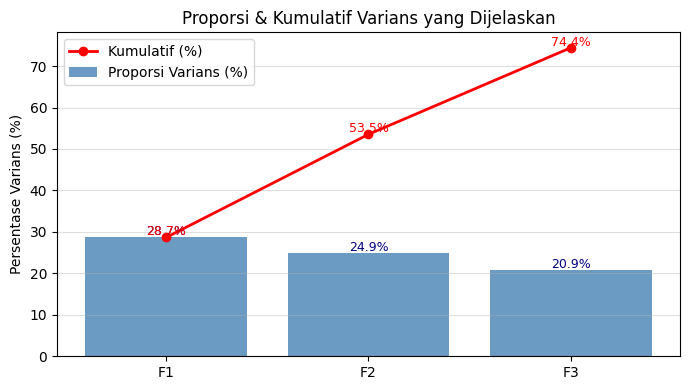

In [ ]:
variance = fa.get_factor_variance()

variance_df = pd.DataFrame(
    variance,
    index=['SS Loadings', 'Proporsi Varians', 'Kumulatif Varians'],
    columns=[f'Factor {i+1}' for i in range(jumlah_faktor)]
).round(4)

print("Tabel Variance Explained:")
print(variance_df)

# Visualisasi proporsi varians
fig, ax = plt.subplots(figsize=(7, 4))
proportions = variance[1] * 100
cumulative  = variance[2] * 100

ax.bar([f'F{i+1}' for i in range(jumlah_faktor)], proportions,
       color='steelblue', alpha=0.8, label='Proporsi Varians (%)')
ax.plot([f'F{i+1}' for i in range(jumlah_faktor)], cumulative,
        marker='o', color='red', linewidth=2, label='Kumulatif (%)')

for i, (p, c) in enumerate(zip(proportions, cumulative)):
    ax.text(i, p + 0.5, f'{p:.1f}%', ha='center', fontsize=9, color='navy')
    ax.text(i, c + 0.5, f'{c:.1f}%', ha='center', fontsize=9, color='red')

ax.set_ylabel("Persentase Varians (%)")
ax.set_title("Proporsi & Kumulatif Varians yang Dijelaskan")
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

Tabel di atas menunjukkan proporsi dan kumulatif varians yang mampu dijelaskan oleh masing-masing faktor. Semakin tinggi nilai kumulatif varians, semakin besar informasi dari data asli yang berhasil diringkas oleh faktor-faktor yang terbentuk.

# Heatmap Rotated Factor Loadings

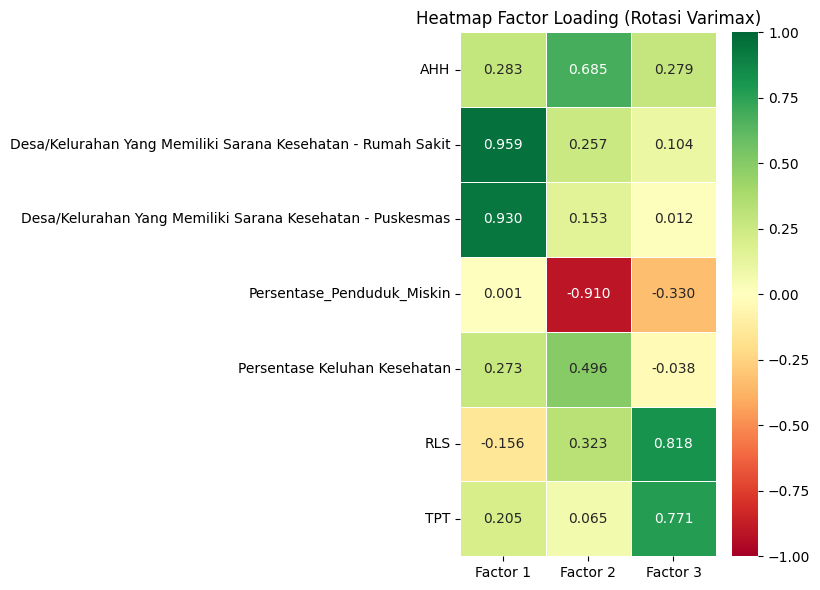


Variabel Dominan per Faktor (|loading| >= 0.5):
  Factor 1: ['Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit', 'Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas']
  Factor 2: ['AHH', 'Persentase_Penduduk_Miskin']
  Factor 3: ['RLS', 'TPT']


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    loading_varimax,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Heatmap Factor Loading (Rotasi Varimax)")
plt.tight_layout()
plt.show()

# Tampilkan variabel dominan per faktor (|loading| >= 0.5)
print("\nVariabel Dominan per Faktor (|loading| >= 0.5):")
for col in loading_varimax.columns:
    dominan = loading_varimax[abs(loading_varimax[col]) >= 0.5].index.tolist()
    print(f"  {col}: {dominan}")

# Communalities

In [ ]:
communalities = pd.DataFrame({
    "Variabel"    : X_iter.columns,
    "Communality" : fa.get_communalities().round(4)
}).sort_values("Communality", ascending=False).reset_index(drop=True)

print("Communalities:")
print(communalities.to_string(index=False))

# Variabel dengan communality rendah (< 0.4) perlu diperhatikan
rendah = communalities[communalities["Communality"] < 0.4]
if not rendah.empty:
    print(f"\nVariabel dengan Communality < 0.4 (perlu diperhatikan):")
    print(rendah.to_string(index=False))
else:
    print("\nSemua variabel memiliki Communality >= 0.4.")

Communalities:
                                                   Variabel  Communality
Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Rumah Sakit       0.9969
                                 Persentase_Penduduk_Miskin       0.9368
  Desa/Kelurahan Yang Memiliki Sarana Kesehatan - Puskesmas       0.8895
                                                        RLS       0.7969
                                                        TPT       0.6407
                                                        AHH       0.6270
                               Persentase Keluhan Kesehatan       0.3215

Variabel dengan Communality < 0.4 (perlu diperhatikan):
                    Variabel  Communality
Persentase Keluhan Kesehatan       0.3215


# Factor Scores

In [ ]:
factor_scores = fa.transform(X_iter)

factor_scores = pd.DataFrame(
    factor_scores,
    columns=[f"Factor {i+1}" for i in range(jumlah_faktor)]
).round(4)

factor_scores.insert(0, "Provinsi", provinsi)

print("Factor Scores (5 baris pertama):")
factor_scores.head()

Factor Scores (5 baris pertama):


,Provinsi,Factor 1,Factor 2,Factor 3
0,ACEH,0.0252,-0.6269,0.7580
1,SUMATERA UTARA,1.2521,0.2613,0.8317
2,SUMATERA BARAT,-0.1917,0.5677,0.4651
3,RIAU,-0.2639,0.7814,-0.0769
4,JAMBI,-0.5296,0.5153,-0.0960


# Export Factor Scores ke CSV

In [ ]:
factor_scores.to_csv("factor_scores.csv", index=False)
print("Factor scores berhasil disimpan ke 'factor_scores.csv'")
print(f"Shape: {factor_scores.shape}")
factor_scores

Factor scores berhasil disimpan ke 'factor_scores.csv'
Shape: (38, 4)


,Provinsi,Factor 1,Factor 2,Factor 3
0,ACEH,0.0252,-0.6269,0.7580
1,SUMATERA UTARA,1.2521,0.2613,0.8317
2,SUMATERA BARAT,-0.1917,0.5677,0.4651
3,RIAU,-0.2639,0.7814,-0.0769
4,JAMBI,-0.5296,0.5153,-0.0960
5,SUMATERA SELATAN,0.0425,0.1576,-0.4242
6,BENGKULU,-0.5057,-0.0972,-0.3570
7,LAMPUNG,-0.1222,0.1035,-0.4393
8,KEP. BANGKA BELITUNG,-0.7704,0.9370,-0.3910
9,KEP. RIAU,-0.7660,0.4928,1.2020
